# A/B Test Analysis

## Analysis objectives
The objective of this analysis is to understand which version of the test A/B are the most valueable for the company.

For this, we will use the **orders_us.csv** and **visits_us.csv** which contains the results of the test, with the following columns/data:

**orders_us.csv**
- **transactionId** — order identifier
- **visitorId** — identifier of the user who placed the order
- **date** — order date
- **revenue** — order revenue
- **group** — A/B test group the user belongs to

**visits_us.csv**
- **date** — date
- **group** — A/B test group
- **visits** — number of visits on the specified date for the specified A/B test group


In [59]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [60]:
# Loading the orders and visits data from a CSV file
df_orders = pd.read_csv("../data/orders_us.csv", parse_dates=["date"])
df_visits = pd.read_csv("../data/visits_us.csv", parse_dates=["date"])

In [61]:
# Displaying dataframe orders information
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[us]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 46.9 KB


In [62]:
# Displaying the first few rows of the orders DataFrame
df_orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [63]:
# Displaying the total number of unique orders (transactions)
df_orders['transactionId'].nunique()

1197

In [64]:
# Checking for duplcated rows in the orders DataFrame
df_orders[df_orders.duplicated()].shape[0]

0

In [65]:
# Identifying visitors that belong to more than one group (A/B test groups)
unusefull_data = df_orders.groupby(
    'visitorId')['group'].nunique().loc[lambda x: x > 1].reset_index()

In [66]:
# Count of visitors that belong to more than one group
print(unusefull_data['visitorId'].count())

58


In [67]:
# Filtering out visitors that belong to more than one group from the orders DataFrame
df_orders_filtered = df_orders[df_orders['visitorId'].isin(
    unusefull_data['visitorId']) == False]

In [68]:
# Displaying the number of rows in the filtered orders DataFrame
print(df_orders.shape[0] - df_orders_filtered.shape[0])

181


In [69]:
# Displaying the group distribution per test
df_orders_filtered['group'].value_counts()

group
B    548
A    468
Name: count, dtype: int64

In [70]:
# Displaying the statistical summary of the 'revenue' column in the filtered orders DataFrame
df_orders_filtered['revenue'].describe()

count     1016.000000
mean       130.770866
std        648.079810
min          5.000000
25%         20.775000
50%         50.100000
75%        126.950000
max      19920.400000
Name: revenue, dtype: float64

In [71]:
# Displaying dataframe visits information
df_visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[us]
 1   group   62 non-null     str           
 2   visits  62 non-null     int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.6 KB


In [72]:
# Displaying first few rows of the visits DataFrame
df_visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [73]:
# Verifying dates range in both DataFrames
print(
    f"Orders date range: \"{df_orders_filtered['date'].min()}\" to \"{df_orders_filtered['date'].max()}\"")
print(
    f"Visits date range: \"{df_visits['date'].min()}\" to \"{df_visits['date'].max()}\"")

Orders date range: "2019-08-01 00:00:00" to "2019-08-31 00:00:00"
Visits date range: "2019-08-01 00:00:00" to "2019-08-31 00:00:00"


### EDA comments
- df_orders have no missing values or duplicated rows
- 'transctionId' uniqueness was verified
- 58 'visitorId' had acess to both tests A and B, 181 rows were removed from dataframe
- test 'A' had 468 orders and 'B' 548
- 'revenue' min and max values are in positive range; distribution seems to have a right-skewed distribution as 75% of data is bellow 126.95 (will be showed later in analysis)
- both dataframes are in the same dates range, from 01-aug-2019 to 31-aug-2019 (1 month)

## 1.Cumulative revenue per group

In [74]:
# Extracting unique date and group combinations
datesGroups = df_orders_filtered[['date', 'group']].drop_duplicates()

In [75]:
# Creating the dataframe with aggregated orders data by date and group
ordersAggregated = datesGroups.apply(
    # For each date and group combination, we filter the orders DataFrame
    lambda x: df_orders_filtered[
        # Include only rows where the date is less than or equal to the current date and the group matches the current group
        np.logical_and(
            df_orders_filtered['date'] <= x['date'], df_orders_filtered['group'] == x['group'])].agg(
        {
            # Get the max date (which is the same as the current date)
            'date': 'max',
            # Get the max group (which is the same as the current group)
            'group': 'max',
            # Count the number of unique orders (transactions)
            'transactionId': pd.Series.nunique,
            # Count the number of unique users (visitors)
            'visitorId': pd.Series.nunique,
            'revenue': 'sum',  # Sum the revenue for the current date and group
        }
    ), axis=1  # Apply the aggregation function along the rows
    # Sort the resulting DataFrame by date and group
).sort_values(by=['date', 'group'])

In [76]:
print(ordersAggregated.head())

          date group  transactionId  visitorId  revenue
55  2019-08-01     A             23         19   2266.6
66  2019-08-01     B             17         17    967.2
175 2019-08-02     A             42         36   3734.9
173 2019-08-02     B             40         39   3535.3
291 2019-08-03     A             66         60   5550.1


In [77]:
# Creating a DataFrame for cumulative revenue of group A
cumulativeRevenueA = ordersAggregated[ordersAggregated['group'] == 'A'][[
    'date', 'revenue']].reset_index(drop=True)

In [78]:
# Creating a DataFrame for cumulative revenue of group B
cumulativeRevenueB = ordersAggregated[ordersAggregated['group'] == 'B'][[
    'date', 'revenue']].reset_index(drop=True)

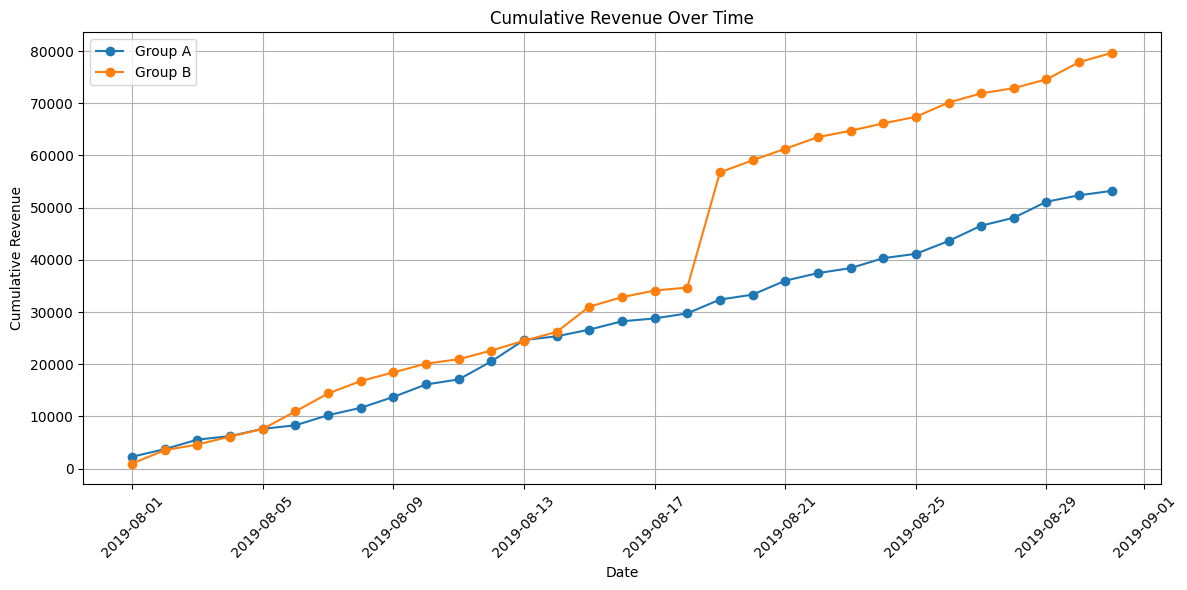

In [79]:
# Plotting cumulative revenue for both groups
plt.figure(figsize=(12, 6))
plt.plot(cumulativeRevenueA['date'],
         cumulativeRevenueA['revenue'], label='Group A', marker='o')
plt.plot(cumulativeRevenueB['date'],
         cumulativeRevenueB['revenue'], label='Group B', marker='o')
plt.title('Cumulative Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Cumulative revenue per group - observations
- Both groups show a steady, roughly linear increase in cumulative revenue over the month, which is expected for a cumulative metric.
- Group B has a higher cumulative revenue than group A from around day 5 onwards, but the gap stays small and fairly constant until day 19.
- On day 19, group B's cumulative revenue jumps sharply. This is likely caused by one or a few very large orders (outliers), rather than a real change in user behavior.
- Because of this spike, group B ends the month clearly ahead of group A, but this lead may be driven mostly by that single anomaly.
- This needs to be checked further: in the next steps we will look at order prices and percentiles and compare the results with and without outliers to see if group B is really performing better.

## 2.Cumulative average ticket per group

In [80]:
# Adding cumulative orders count column to the cumulativeRevenueA DataFrame
cumulativeRevenueA['orders'] = ordersAggregated[ordersAggregated['group']
                                                == 'A']['transactionId'].reset_index(drop=True)

In [81]:
# Adding cumulative orders count column to the cumulativeRevenueB DataFrame
cumulativeRevenueB['orders'] = ordersAggregated[ordersAggregated['group']
                                                == 'B']['transactionId'].reset_index(drop=True)

In [82]:
# Calculating the cumulative average order size for group A
avgOrderSizeA = cumulativeRevenueA['revenue'] / cumulativeRevenueA['orders']

In [83]:
# Calculating the cumulative average order size for group B
avgOrderSizeB = cumulativeRevenueB['revenue'] / cumulativeRevenueB['orders']

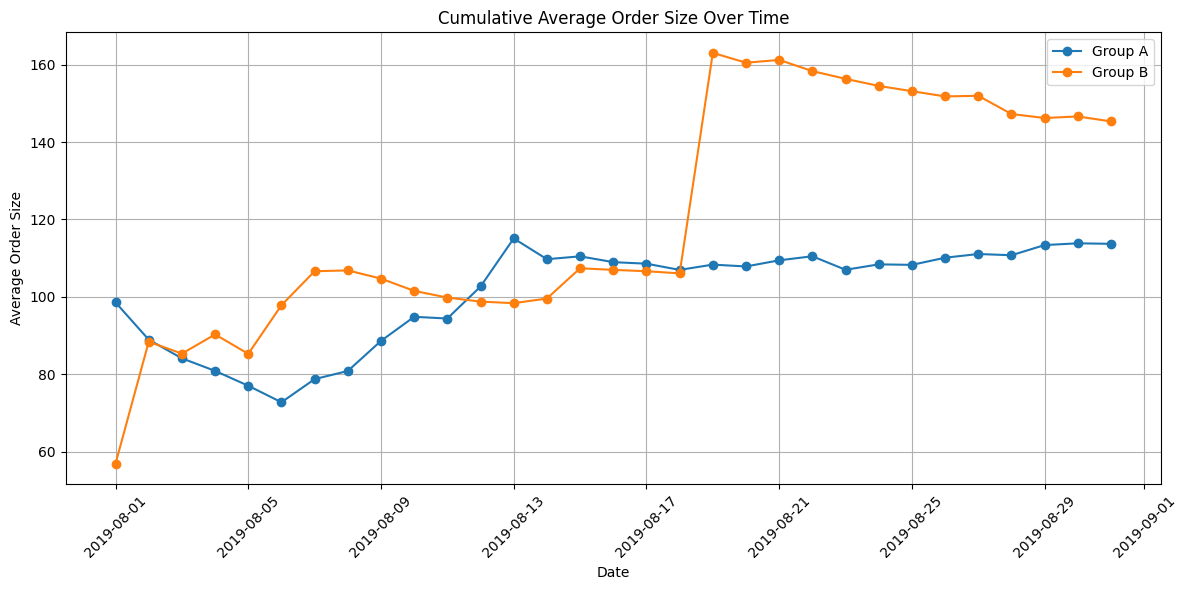

In [84]:
# Plotting cumulative revenue for both groups
plt.figure(figsize=(12, 6))
plt.plot(cumulativeRevenueA['date'], avgOrderSizeA,
         label='Group A', marker='o')
plt.plot(cumulativeRevenueB['date'], avgOrderSizeB,
         label='Group B', marker='o')
plt.title('Cumulative Average Order Size Over Time')
plt.xlabel('Date')
plt.ylabel('Average Order Size')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Cumulative average ticket per group - observations
- Group B has a higher average ticket than group A in the big picture: by the end of the month, B's average order is ~145.3 vs A's ~113.7, about 28% higher.
- Group A has higher average ticket in the first day and again between days 12 and 18. With only a handful of orders accumulated so early in the test, the average is noisy and can swing a lot - these early crossovers are less meaningful than the later, more stable trend.
- On day 19, group B's average ticket jumps sharply (from ~106 to ~163). This is likely caused by one or a few very large orders (outliers), rather than a real change in user behavior.
- Because of this spike, group B ends the month clearly ahead of group A, but this lead may be driven mostly by that single anomaly.
- This needs to be checked further: in the next steps we will look at order prices and percentiles and compare the results with and without outliers to see if group B is really performing better.

## 3. Average ticket relative diference between group B and A

In [85]:
# Merging cumulative revenue DataFrames for both groups on the 'date' column
mergedCumulativeRevenue = cumulativeRevenueA.merge(
    cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

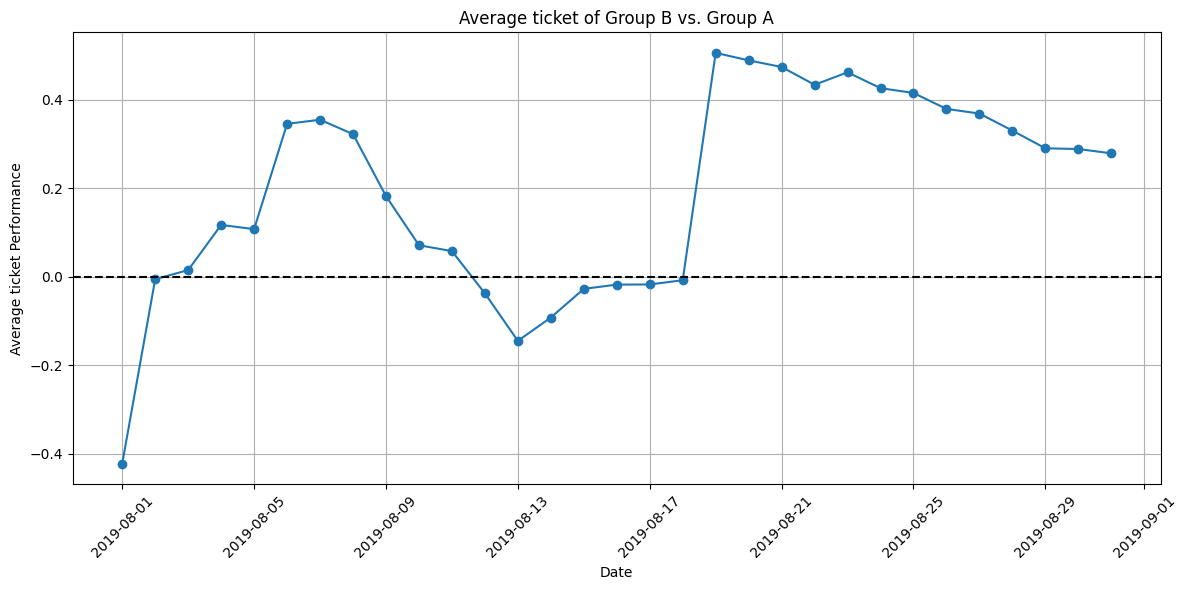

In [86]:
# Plotting the average ticket of Group B vs. Group A
plt.figure(figsize=(12, 6))
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(
    mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1, marker='o')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Average ticket of Group B vs. Group A')
plt.xlabel('Date')
plt.ylabel('Average ticket Performance')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

### Average ticket relative diference - observations
- Group B shows a higher cumulative average ticket when compared to Group A throughout almost the whole month, ending the month ~28% higher.
- Near the 19th day we see a sharp spike, where B's lead over A peaks at ~50%, probably due to one or a few large outlier orders.
- After the spike, the relative difference slowly decreases from ~50% to ~28% by day 31. This happens because the cumulative average gets diluted as more (normal-sized) orders are added to the total after day 19 - the outlier's weight on the average shrinks as the order count grows. This is expected behavior for a cumulative metric once an outlier enters the data, and it confirms the spike is a one-off event rather than a sustained shift.
- We need to analyze further without outliers to confirm if Group B had better results than Group A independently of this anomaly.

## 4. Daily Conversion Rate per group

In [87]:
# Getting the number of unique orders (transactions) per date and group
dailyOrders = df_orders_filtered.groupby(['date', 'group'])[
    'transactionId'].nunique().reset_index(name='orders')

In [88]:
# Merging the daily orders DataFrame with the visits DataFrame to calculate conversion rates
conversion = dailyOrders.merge(df_visits, on=['date', 'group'], how='left')

In [89]:
# Calculating the conversion rate
conversion['conversionRate'] = conversion['orders'] / \
    conversion['visits'] * 100

In [90]:
# Creating a DataFrame for conversion rates of group A
conversionGroupA = conversion[conversion['group'] == 'A'][[
    'date', 'conversionRate']].reset_index(drop=True)

In [91]:
# Creating a DataFrame for conversion rates of group B
conversionGroupB = conversion[conversion['group'] == 'B'][[
    'date', 'conversionRate']].reset_index(drop=True)

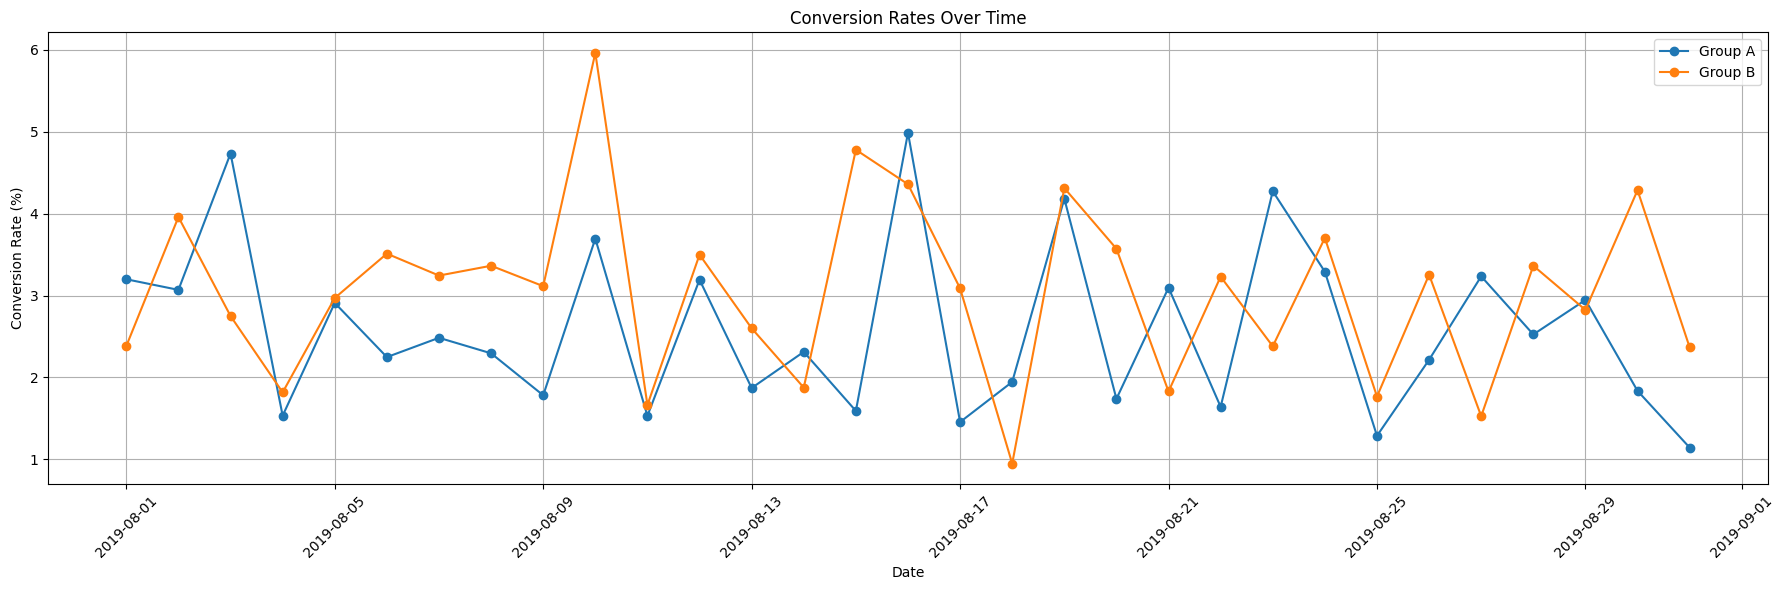

In [92]:
plt.figure(figsize=(18, 6))
plt.plot(conversionGroupA['date'], conversionGroupA['conversionRate'],
         label='Group A', marker='o')
plt.plot(conversionGroupB['date'], conversionGroupB['conversionRate'],
         label='Group B', marker='o')
plt.title('Conversion Rates Over Time')
plt.xlabel('Date')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Daily convertion rate - observations
- Both groups show an up and down behavior in conversion rates over time; those oscillations are similar between both groups. This is expected, since daily conversion rates are based on a small number of orders out of hundreds of visits, so day-to-day swings of 1-2 percentage points are normal noise rather than a real change in behavior.
- Group B accumulates more days with a conversion rate above Group A (22 out of 31 days).
- We can observe two spikes in Group B: a notably high positive spike at day 10 (~6%) and the lowest value of the entire period at day 18 (~1%). These are daily conversion outliers, separate from the large single-order revenue spike seen on day 19 in the cumulative charts - they reflect unusually low/high order counts on those specific days, not unusually large order values.

## 5. Orders per user per group — Distribution

In [93]:
# Calculating the average number of orders per user
ordersByUsers = (
    df_orders_filtered.drop(['group', 'revenue', 'date'], axis=1)
    .groupby('visitorId', as_index=False)
    .agg({'transactionId': pd.Series.nunique})
)

In [94]:
# Renaming the columns
ordersByUsers.columns = ['userId', 'orders']

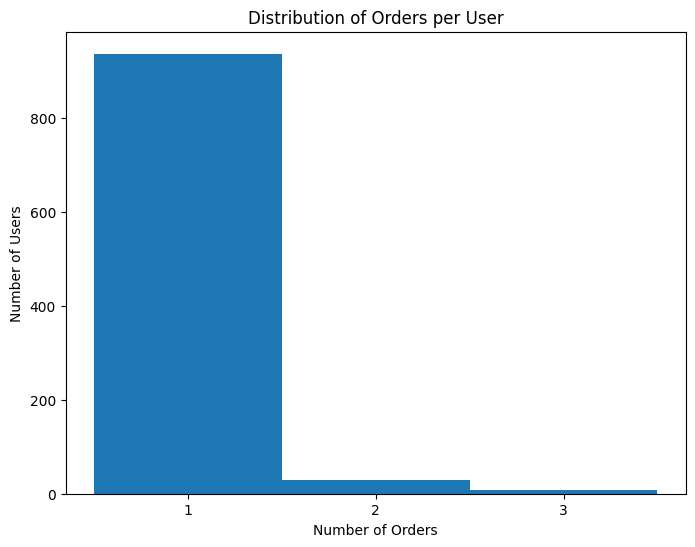

In [95]:
# Ploting an histogram
plt.figure(figsize=(8, 6))
plt.hist(ordersByUsers['orders'], bins=[0.5, 1.5, 2.5, 3.5])
plt.title('Distribution of Orders per User')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Users')
plt.xticks(range(1, ordersByUsers['orders'].max() + 1))
plt.show()

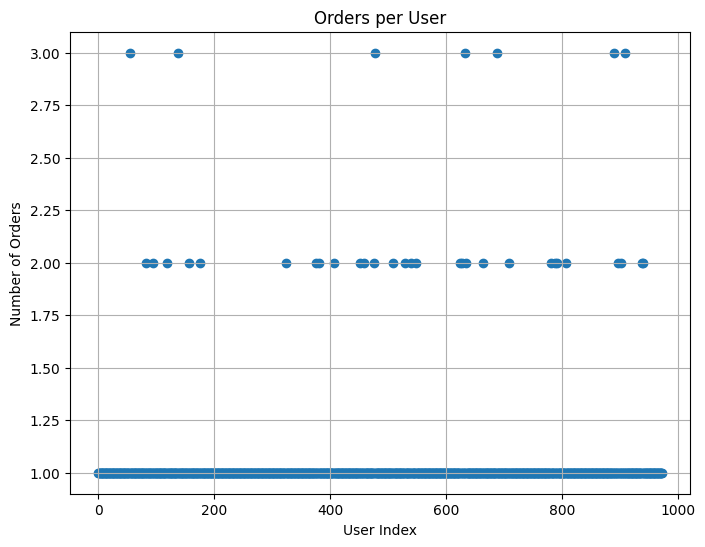

In [96]:
# defining the x values for the scatter plot
x_values = pd.Series(range(0, len(ordersByUsers)))

# Ploting a scatter plot of orders per user
plt.figure(figsize=(8, 6))
plt.scatter(x_values, ordersByUsers['orders'])
plt.title('Orders per User')
plt.xlabel('User Index')
plt.ylabel('Number of Orders')
plt.grid()
plt.show()

### Orders per user per group — observations
- The number of orders per user are distributed between 1 (most common), 2 (some users) and 3 (few users).
- Most users made only one order and did not make a second one, retention can be improved.
- Further investigation is needed to conclude if 3 orders should be considered an outlier, as we have no evident outliers in data.

## 6. Orders per user — percentiles

In [97]:
# Checking 95th and 99th percentiles of the number of orders per user
print(np.percentile(ordersByUsers['orders'], [95, 99]))

[1. 2.]


### Orders per user percentiles - observations
- Percentile 95 = 1, so 95% of the users made 1 order or less.
- Percentile 99 = 2, so 99% of the users made 2 orders or less.
- Users with 3 orders must be considered outliers.
- We will consider outliers the top 1%, otherwise insightful data can be removed.

## 7. Revenue distribution - scatter plot

In [98]:
# Calculating the total revenue per user
revenueByUsers = (
    df_orders_filtered.drop(['group', 'date'], axis=1)
    .groupby('visitorId', as_index=False)
    .agg({'revenue': 'sum'})
)

In [99]:
# Calculating the average revenue per user
avgRevenueByUser = revenueByUsers['revenue'].mean()
print(f"Average revenue per user: {avgRevenueByUser:.2f}")

Average revenue per user: 136.55


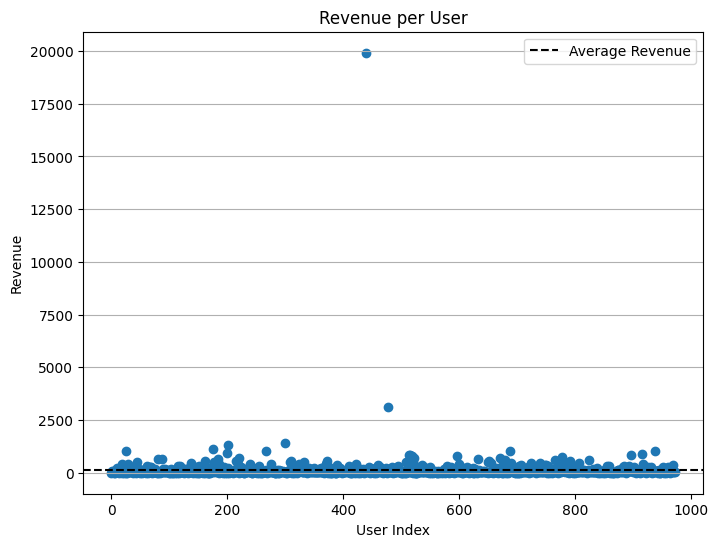

In [100]:
# Definig the x values for the scatter plot
x_values = pd.Series(range(0, len(revenueByUsers['revenue'])))

# Ploting a scatter plot of revenue per user
plt.figure(figsize=(8, 6))
plt.scatter(x_values, revenueByUsers['revenue'])
plt.axhline(y=avgRevenueByUser, color='black',
            linestyle='--', label='Average Revenue')
plt.title('Revenue per User')
plt.xlabel('User Index')
plt.ylabel('Revenue')
plt.grid(axis='y')
plt.legend()
plt.show()

### Revenue distribution - scatter plot - observations
- We can observe most of users revenue distribution is near the average amount of 136.55
- Two clear outliers are visible, one near 20k and other near 3k
- In the next step, we will calculate percentiles to confirm whether more outliers exist in the data.

## 8. Revenue per user - percentiles

In [101]:
# Checking 95th and 99th percentiles of the revenue per user
print(np.percentile(revenueByUsers['revenue'], [95, 99]))

[449.5   912.576]


### Revenue per user percentiles - observations
- Percentile 95 = 449.5, so 95% of the users spent 449.5 or less.
- Percentile 99 = 912.58, so 99% of the users spent 912.58 or less.
- Users that spent more than 912.58 must be considered outliers.
- We will consider outliers the top 1%, otherwise insightful data can be removed.

## 9. Statistical significance - conversion rate (raw data)

In [102]:
# Calculating the total number of orders per user for group A
ordersByUsersA = (
    df_orders_filtered[df_orders_filtered['group'] == 'A']
    .groupby('visitorId', as_index=False)
    .agg({'transactionId': pd.Series.nunique, })
)
ordersByUsersA.columns = ['visitorId', 'orders']

In [103]:
# Calculating the total number of orders per user for group B
ordersByUsersB = (
    df_orders_filtered[df_orders_filtered['group'] == 'B']
    .groupby('visitorId', as_index=False)
    .agg({'transactionId': pd.Series.nunique})
)
ordersByUsersB.columns = ['visitorId', 'orders']

In [104]:
# Calculating the total number of visits for group A
totalVisitsA = df_visits[df_visits['group'] == 'A']['visits'].sum()

In [105]:
# Calculating the total number of visits for group B
totalVisitsB = df_visits[df_visits['group'] == 'B']['visits'].sum()

In [106]:
# Creating sample for the orders per user for group A
sampleAOrders = pd.concat([
    ordersByUsersA['orders'],
    pd.Series(0, index=np.arange(totalVisitsA - len(ordersByUsersA)))
])

In [107]:
# Creating sample for the orders per user for group B
sampleBOrders = pd.concat([
    ordersByUsersB['orders'],
    pd.Series(0, index=np.arange(totalVisitsB - len(ordersByUsersB)))
])

In [108]:
# Checking the distribution of orders per visitor for both samples
print(f"Sample A orders per visitor:\n{sampleAOrders.value_counts()}")
print(f"Sample B orders per visitor:\n{sampleBOrders.value_counts()}")

Sample A orders per visitor:
0    18291
1      427
2       13
3        5
Name: count, dtype: int64
Sample B orders per visitor:
0    18388
1      510
2       16
3        2
Name: count, dtype: int64


### The hypotheses

Null hypothesis (H₀): there is no difference between group A and group B — any difference we see in the data is just random noise.

Alternative hypothesis (H₁): there is a real difference between the groups.

### Statistical Test Selection
- Sample A and Sample B distributions are mostly populated by '0' (zero), with a long right-tailed skew toward higher values.
- A normal distribution is not verified so the Mann-Whitney test is the appropriate test to apply in this analysis.


In [109]:
# Defining the significance level for the Mann-Whitney U test
alpha = 0.05

# Performing the Mann-Whitney U test to compare the two samples
resultsOrders = stats.mannwhitneyu(sampleAOrders, sampleBOrders)
print(f"p-value: {resultsOrders.pvalue:.3f}")

# Interpreting the results of the Mann-Whitney U test
if resultsOrders.pvalue < alpha:
    print("Reject H0: significant difference in conversion rate")
else:
    print("Fail to reject H0: no significant difference detected")

p-value: 0.011
Reject H0: significant difference in conversion rate


### Observations
- After running the Mann-Whitney test in the raw data (outliers included), the null hypothesis must be rejected.
- p-value is smaller than the significance level, this is strong evidence of a real difference in conversion rate between the groups.
- This confirms that Group B's higher conversion rate observed in task 4 is statistically significant, not due to random variation — Group B converts at a higher rate than Group A.

## 10. Statistical significance - average ticket (raw data)

### The hypotheses

Null hypothesis (H₀): there is no difference between group A and group B — any difference we see in the data is just random noise.

Alternative hypothesis (H₁): there is a real difference between the groups.

### Statistical Test Selection

- We observed earlier that group B finished with 28% higher average ticket than group A.
- We verified a mean value of 130.77 and a max value of 19,920.4.
- A normal distribution is not verified so the Mann-Whitney test is the appropriate test to apply in this analysis.

In [ ]:
# Creating sample for the revenue per user for group A
sampleATicket = df_orders_filtered[df_orders_filtered['group']
                                   == 'A']['revenue']

In [ ]:
# Creating sample for the revenue per user for group B
sampleBTicket = df_orders_filtered[df_orders_filtered['group']
                                   == 'B']['revenue']

In [112]:
# defining the significance level for the Mann-Whitney U test
alpha = 0.05

# Performing the Mann-Whitney U test to compare the two samples
resultsTicket = stats.mannwhitneyu(sampleATicket, sampleBTicket)
print(f"p-value: {resultsTicket.pvalue:.3f}")

# Interpreting the results of the Mann-Whitney U test
if resultsTicket.pvalue < alpha:
    print("Reject H0: significant difference in average ticket value")
else:
    print("Fail to reject H0: no significant difference detected")

p-value: 0.862
Fail to reject H0: no significant difference detected


### Observations
- After running the Mann-Whitney test in the raw data (outliers included), we fail to reject the null hypothesis.
- p-value is considerably higher than the significance level, so we have no strong evidence of a real difference in average ticket between the groups.
- This confirms that Group B's higher average ticket observed in tasks 2 and 3 is not statistically significant. Group B's higher performance may be due to the outliers observed in the revenue data.

## 11. Statistical significance - conversion rate (outliers removed)

- As we conclude in task 6, we consider outliers all the orders bigger than 2.

In [ ]:
# Removing outliers from the orders per user for group A
ordersByUsersANoOutliers = ordersByUsersA[ordersByUsersA['orders'] < 3]

In [114]:
# Removing outliers from the orders per user for group B
ordersByUsersBNoOutliers = ordersByUsersB[ordersByUsersB['orders'] < 3]

In [ ]:
# Creating sample for the orders per user for group A - no outliers
sampleAOrdersNoOutliers = pd.concat([
    ordersByUsersANoOutliers['orders'],
    pd.Series(0, index=np.arange(totalVisitsA - len(ordersByUsersANoOutliers)))
])

In [116]:
# Creating sample for the orders per user for group B - no outliers
sampleBOrdersNoOutliers = pd.concat([
    ordersByUsersBNoOutliers['orders'],
    pd.Series(0, index=np.arange(totalVisitsB - len(ordersByUsersBNoOutliers)))
])

In [ ]:
# defining the significance level for the Mann-Whitney U test
alpha = 0.05

# Performing the Mann-Whitney U test to compare the two samples
resultsOrders = stats.mannwhitneyu(
    sampleAOrdersNoOutliers, sampleBOrdersNoOutliers)
print(f"p-value: {resultsOrders.pvalue:.3f}")

# Interpreting the results of the Mann-Whitney U test
if resultsOrders.pvalue < alpha:
    print("Reject H0: significant difference in conversion rate")
else:
    print("Fail to reject H0: no significant difference detected")

p-value: 0.008
Reject H0: significant difference in conversion rate


### Observations
- After removing the orders that have more than 2, the p-value assumes a smaller value.
- We increase the difference between the p-value and the alpha, which reinforces that we should reject H0.
- This confirms the task 9 result holds even after removing outliers: Group B has a statistically significant higher conversion rate than Group A, and removing the small number of high-order outliers makes this difference even clearer.